In [14]:
import os
from datetime import datetime
import socket
import logging
import argparse
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter

SYSTEM_ID = socket.gethostname()
DATETIME_ID = datetime.now().strftime("%b%d_%H-%M")

logger = logging.getLogger("simple_logger")
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(
    "%(asctime)s - %(levelname)s - %(message)s", datefmt="%Y-%m-%d %H:%M:%S"
)
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.DEBUG)
console_handler.setFormatter(formatter)

logger.addHandler(console_handler)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
def load_cifar10(batch_size=64):
    train_transform = transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(1.0, 1.0, 1.0)),
        ]
    )
    trainset = torchvision.datasets.CIFAR10(
        root="../data/raw", train=True, download=True, transform=train_transform
    )
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=2
    )

    test_transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(1.0, 1.0, 1.0)),
        ]
    )

    testset = torchvision.datasets.CIFAR10(
        root="../data/raw", train=False, download=True, transform=test_transform
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return trainloader, testloader


train_loader, test_loader = load_cifar10(batch_size=64)

Files already downloaded and verified
Files already downloaded and verified


In [17]:
train_transform = transforms.Compose(
    [
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomCrop(32, padding=4),
        # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        # transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(1.0, 1.0, 1.0)),
    ]
)

trainset = torchvision.datasets.CIFAR10(
    root="../data/raw", train=True, download=True, transform=train_transform
)

Files already downloaded and verified


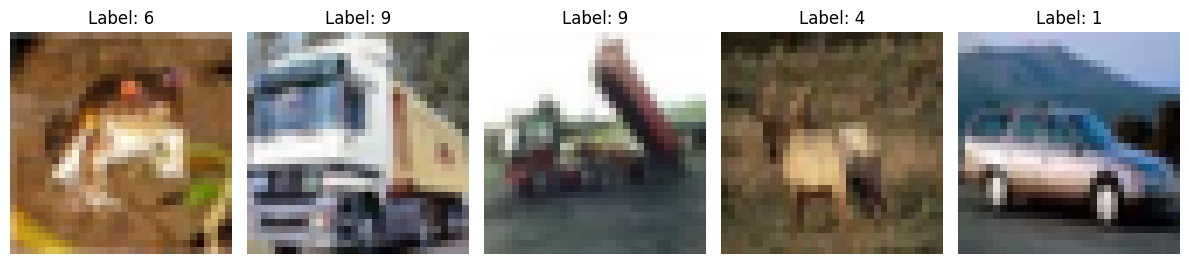

In [33]:
num_images = 5
fig, axes = plt.subplots(nrows=1, ncols=num_images, figsize=(12, 3))
for i, (image, label) in enumerate(trainset):
    if i >= num_images:
        break
    image, label = trainset[i]

    axes[i].imshow(image.permute(1, 2, 0))
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")


plt.tight_layout()
plt.show()

In [40]:
sample_0 = trainset[0][0]

sample_0_mean = torch.mean(sample_0, dim=0)

In [59]:
sample_0[:, 0, 0], sample_0[:, 0, 1]

(tensor([0.2314, 0.2431, 0.2471]), tensor([0.1686, 0.1804, 0.1765]))

In [62]:
torch.norm(sample_0[:, 0, 0] - sample_0[:, 0, 1], dim=0)

tensor(0.1134)

In [128]:
cur_h, cur_w = 21, 19

A = torch.zeros(32, 32)
for h in range(32):
    for w in range(32):
        A[h, w] = torch.norm(sample_0[:, cur_h, cur_w] - sample_0[:, h, w], dim=0)

flattened_indices = torch.topk(A.flatten(), k=10, largest=False).indices

row_indices = flattened_indices // 32
col_indices = flattened_indices % 32

smallest_values = A[row_indices, col_indices]
indices_of_smallest_values = list(zip(row_indices.tolist(), col_indices.tolist()))

smallest_values, indices_of_smallest_values, A

(tensor([0.0000, 0.0055, 0.0068, 0.0124, 0.0130, 0.0141, 0.0141, 0.0147, 0.0147,
         0.0162]),
 [(21, 19),
  (28, 23),
  (23, 21),
  (21, 18),
  (10, 22),
  (23, 16),
  (26, 25),
  (28, 6),
  (27, 7),
  (27, 26)],
 tensor([[0.3595, 0.4440, 0.4172,  ..., 0.2513, 0.2131, 0.2124],
         [0.6012, 0.7146, 0.6430,  ..., 0.0895, 0.1151, 0.0957],
         [0.5632, 0.6511, 0.4992,  ..., 0.1156, 0.1096, 0.1758],
         ...,
         [0.4090, 0.3186, 0.3399,  ..., 0.1558, 0.4718, 0.4560],
         [0.2675, 0.1573, 0.2591,  ..., 0.2925, 0.2460, 0.3079],
         [0.3258, 0.2169, 0.2521,  ..., 0.5510, 0.1390, 0.1073]]))

In [266]:
sample = trainset[0][0]


def get_list_of_KNN(image_tensor, h, w, flattened=True):
    cur_h, cur_w = h, w

    knn_matrix = torch.zeros(32, 32)
    for h in range(32):
        for w in range(32):
            knn_matrix[h, w] = torch.norm(
                image_tensor[:, cur_h, cur_w] - image_tensor[:, h, w], dim=0
            )

    knn_matrix_flattened = knn_matrix.flatten()
    flattened_indices = torch.topk(knn_matrix_flattened, k=5, largest=False).indices
    if flattened:
        return knn_matrix_flattened, flattened_indices

    row_indices = flattened_indices // 32
    col_indices = flattened_indices % 32

    smallest_values = knn_matrix[row_indices, col_indices]
    indices_of_smallest_values = list(zip(row_indices.tolist(), col_indices.tolist()))

    return smallest_values, indices_of_smallest_values


def get_A_per_image(sample):  # sample: Tuple[imageTensor, label]
    A = torch.zeros((32, 32))
    for h in range(32):
        for w in range(32):
            _, cur_indices = get_list_of_KNN(sample[0], h, w, flattened=False)
            A[cur_indices[0], cur_indices[1]] = 1
    return A

In [173]:
def get_flattened_index(tuple_of_index):
    return tuple_of_index[0] * 32 + tuple_of_index[1]

In [185]:
_, list_of_indices = get_list_of_KNN(0, 0, flattened=False)
list_of_indices

[(0, 0), (0, 3), (0, 2), (0, 1), (16, 6)]

In [219]:
test_image_0, test_label_image_0 = trainset[12]
processed_sample_0 = get_A_per_image(trainset[12])

In [ ]:
processed_sample_0

(tensor([[1., 1., 1.,  ..., 0., 1., 1.],
         [1., 1., 1.,  ..., 1., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 1.],
         ...,
         [0., 0., 0.,  ..., 1., 1., 1.],
         [1., 0., 0.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]),
 1)

In [ ]:
test_image_0.shape

torch.Size([3, 32, 32])

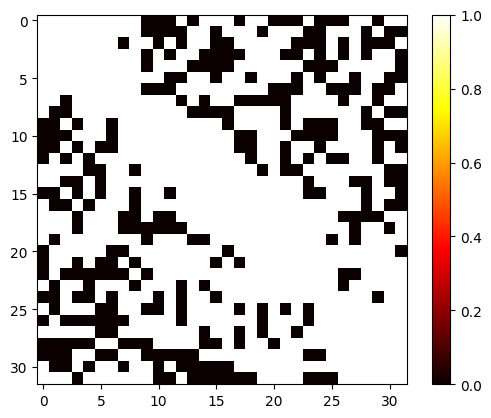

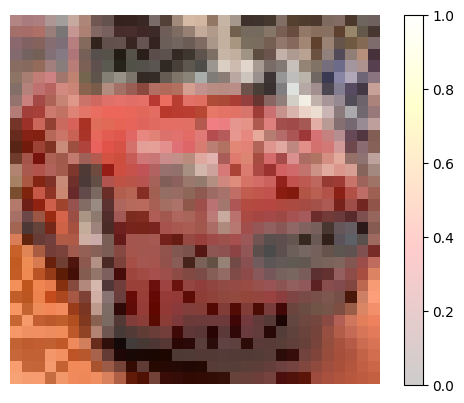

In [ ]:
def plot_A_for_image(A):
    plt.imshow(A, cmap="hot", interpolation="nearest")
    plt.colorbar()  # for the case that it's weighted
    plt.show()


def plot_A_over_image(A, sample):
    image_tensor = sample

    plt.imshow(image_tensor.permute(1, 2, 0))
    plt.axis("off")
    plt.imshow(A, cmap="hot", alpha=0.2)
    plt.colorbar()
    plt.show()

In [ ]:
num_images = 5
fig, axes = plt.subplots(nrows=1, ncols=num_images, figsize=(12, 3))
for i, (image, label) in enumerate(trainset):
    if i >= num_images:
        break
    image, label = trainset[i]

    axes[i].imshow(image.permute(1, 2, 0))
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")


plt.tight_layout()
plt.show()

In [ ]:
## PREPARING FOR LOADING IN THE DATALOADER
sample_size = 10


def get_node_features_for_image(sample):
    return sample[0].view(3, -1).T


node_features = [
    get_node_features_for_image(trainset[idx]) for idx in range(0, sample_size)
]
targets = [trainset[idx][1] for idx in range(0, sample_size)]
adjacency_matrices = [get_A_per_image(trainset[idx]) for idx in range(0, sample_size)]

In [ ]:
import torch
from torch_geometric.data import Data, Dataset


class CustomGraphDataset(Dataset):
    def __init__(self, adjacency_matrices, node_features, targets=None):
        self.adjacency_matrices = adjacency_matrices
        self.node_features = node_features
        self.targets = targets

    def __len__(self):
        return len(self.adjacency_matrices)

    def __getitem__(self, idx):
        adj_matrix = self.adjacency_matrices[idx]
        node_feat = self.node_features[idx]
        target = self.targets[idx] if self.targets is not None else None

        edge_index = (
            torch.tensor(adj_matrix.nonzero(), dtype=torch.long).t().contiguous()
        )
        x = torch.tensor(node_feat, dtype=torch.float)

        data = Data(x=x, edge_index=edge_index)

        if target is not None:
            data.y = torch.tensor(target, dtype=torch.long)

        return data

In [248]:
trainset[0]

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

[tensor([[0.2314, 0.2431, 0.2471],
         [0.1686, 0.1804, 0.1765],
         [0.1961, 0.1882, 0.1686],
         ...,
         [0.8471, 0.7216, 0.5490],
         [0.5922, 0.4627, 0.3294],
         [0.4824, 0.3608, 0.2824]]),
 tensor([[0.6039, 0.6941, 0.7333],
         [0.4941, 0.5373, 0.5333],
         [0.4118, 0.4078, 0.3725],
         ...,
         [0.5608, 0.5216, 0.5451],
         [0.5608, 0.5255, 0.5569],
         [0.5608, 0.5216, 0.5647]])]

In [287]:
import torch
from torch_geometric.data import Data, Dataset
import torch
from torch_geometric.data import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F
from torch.nn import Linear


class CustomGraphDataset(Dataset):
    def __init__(self, adjacency_matrices, node_features, targets=None):
        super().__init__()
        self.adjacency_matrices = adjacency_matrices
        self.node_features = node_features
        self.targets = targets

    def len(self):
        return len(self.adjacency_matrices)

    def get(self, idx):
        adj_matrix = self.adjacency_matrices[idx]
        node_feat = self.node_features[idx]
        target = self.targets[idx] if self.targets is not None else None

        edge_index = (
            torch.tensor(adj_matrix.nonzero(), dtype=torch.long).t().contiguous()
        )
        x = torch.tensor(node_feat, dtype=torch.float)

        data = Data(x=x, edge_index=edge_index)

        if target is not None:
            data.y = torch.tensor(target, dtype=torch.long)

        return data


custom_dataset = CustomGraphDataset(adjacency_matrices, node_features, targets)
loader = DataLoader(custom_dataset, batch_size=1, shuffle=True)

In [285]:
class GNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(custom_dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        return F.log_softmax(x, dim=1)


hidden_channels = 64
num_classes = 10
learning_rate = 0.01
num_epochs = 10

loader = DataLoader(custom_dataset, batch_size=1, shuffle=True)
model = GNN(hidden_channels)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    model.train()
    for data in loader:
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()

/tmp/ipykernel_122313/3460014958.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index = torch.tensor(adj_matrix.nonzero(), dtype=torch.long).t().contiguous()
/tmp/ipykernel_122313/3460014958.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(node_feat, dtype=torch.float)


IndexError: list index out of range

In [268]:
test_0 = get_A_per_image(trainset[0])
test_1 = get_A_per_image(trainset[1])
test_43123 = get_A_per_image(trainset[43123])

In [269]:
test_0, test_1, test_43123

(tensor([[1., 0., 1.,  ..., 0., 0., 1.],
         [1., 1., 1.,  ..., 0., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 0.],
         ...,
         [0., 0., 1.,  ..., 1., 1., 1.],
         [0., 0., 1.,  ..., 1., 1., 1.],
         [1., 1., 0.,  ..., 1., 1., 1.]]),
 tensor([[1., 1., 1.,  ..., 0., 1., 1.],
         [1., 1., 1.,  ..., 0., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 0.],
         ...,
         [0., 0., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]),
 tensor([[1., 1., 1.,  ..., 0., 0., 1.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 1., 0., 0.],
         ...,
         [0., 0., 1.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.],
         [1., 0., 1.,  ..., 1., 1., 1.]]))

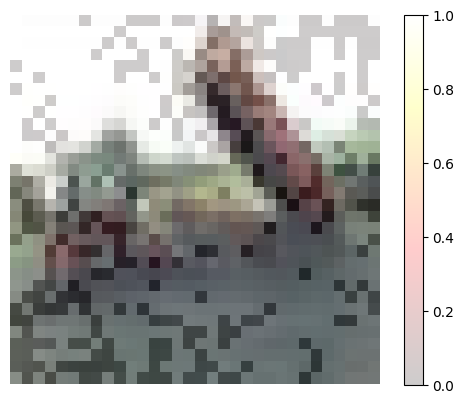

In [279]:
plot_A_over_image(test_43123, trainset[2][0])

In [ ]:
class CustomGraphDataset(Dataset):
    def __init__(self, adjacency_matrices, node_features, targets=None):
        self.adjacency_matrices = adjacency_matrices
        self.node_features = node_features
        self.targets = targets

    def __len__(self):
        return len(self.adjacency_matrices)

    def __getitem__(self, idx):
        adj_matrix = self.adjacency_matrices[idx]
        node_feat = self.node_features[idx]
        target = self.targets[idx] if self.targets is not None else None

        edge_index = (
            torch.tensor(adj_matrix.nonzero(), dtype=torch.long).t().contiguous()
        )
        x = torch.tensor(node_feat, dtype=torch.float)

        data = Data(x=x, edge_index=edge_index)
        if target is not None:
            data.y = torch.tensor(target, dtype=torch.long)

        return data

In [265]:
test_1

(tensor([[1., 1., 0.,  ..., 0., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [0., 1., 1.,  ..., 0., 1., 1.],
         ...,
         [1., 1., 0.,  ..., 1., 1., 1.],
         [0., 1., 0.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]),
 5)

In [245]:
trainset_100 = trainset[0:2]

TypeError: Cannot handle this data type: (1, 1, 32, 3), |u1

In [289]:
trainset_100 = trainset[0:100]

# adjacency_matrices = [your_adjacency_matrix_1, your_adjacency_matrix_2, ...]
# node_features = [your_node_features_1, your_node_features_2, ...]
# targets = [your_targets_1, your_targets_2, ...]

custom_dataset = CustomGraphDataset(adjacency_matrices, node_features, targets)

loader = DataLoader(custom_dataset, batch_size=1, shuffle=True)

for data in loader:
    pass

TypeError: Cannot handle this data type: (1, 1, 32, 3), |u1

In [226]:
trainset[0][0]  # index_0: img out of 50000, index_1: (img, label) | 3x32x32

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [242]:
trainset_flattened = trainset[0][0].view(3, -1).T
trainset_flattened, trainset_flattened.shape

(tensor([[0.2314, 0.2431, 0.2471],
         [0.1686, 0.1804, 0.1765],
         [0.1961, 0.1882, 0.1686],
         ...,
         [0.8471, 0.7216, 0.5490],
         [0.5922, 0.4627, 0.3294],
         [0.4824, 0.3608, 0.2824]]),
 torch.Size([1024, 3]))

tensor([[0.2314, 0.2431, 0.2471],
        [0.1686, 0.1804, 0.1765],
        [0.1961, 0.1882, 0.1686],
        ...,
        [0.8471, 0.7216, 0.5490],
        [0.5922, 0.4627, 0.3294],
        [0.4824, 0.3608, 0.2824]])

In [151]:
sample_0[:, 15, 6]

tensor([0.2588, 0.1686, 0.1216])

In [158]:
sample_0.view(3, -1)[:, get_flattened_index((15, 6))]

tensor([0.2588, 0.1686, 0.1216])

In [ ]:
A = torch.zeros(32, 32)
for flattened_index in range(32 * 32):
    A[32, 32]

In [149]:
sample_0.view(3, -1)

tensor([[0.2314, 0.1686, 0.1961,  ..., 0.8471, 0.5922, 0.4824],
        [0.2431, 0.1804, 0.1882,  ..., 0.7216, 0.4627, 0.3608],
        [0.2471, 0.1765, 0.1686,  ..., 0.5490, 0.3294, 0.2824]])

In [148]:
sample_0

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [74]:
A = torch.zeros(32, 32)
A[0, 0] = torch.norm(sample_0[:, 1, 1] - sample_0[:, 3, 2], dim=0)
A[1, 0] = torch.norm(sample_0[:, 2, 1] - sample_0[:, 4, 2], dim=0)

A

tensor([[0.4133, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.4281, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])

In [52]:
pixel_0_0 = sample_0[:, 0, 0].unsqueeze(dim=1).unsqueeze(dim=1)
pixel_0_0 = sample_0[:, 0, 0].unsqueeze(dim=1).unsqueeze(dim=1)
pixel_0_0.shape

torch.Size([3, 1, 1])

In [56]:
distances = torch.norm(sample_0 - pixel_0_0, dim=0)
distances

tensor([[0.0000, 0.1134, 0.1020,  ..., 0.5072, 0.4663, 0.4534],
        [0.2898, 0.4168, 0.3630,  ..., 0.2727, 0.2544, 0.2668],
        [0.2591, 0.3688, 0.2586,  ..., 0.2521, 0.2594, 0.2170],
        ...,
        [0.7332, 0.6711, 0.6848,  ..., 0.4849, 0.2513, 0.2026],
        [0.5771, 0.5137, 0.6068,  ..., 0.6073, 0.1875, 0.1518],
        [0.6006, 0.5163, 0.5734,  ..., 0.8361, 0.4303, 0.2794]])

In [50]:
pixel_0_0 = sample_0[:, 0, 0]
torch.cdist(pixel_0_0.unsqueeze(dim=1), sample_0)

RuntimeError: X1 and X2 must have the same number of columns. X1: 1 X2: 32